In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy

## Linear regression from scratch in numpy

*Illustrating the idea of rates of change with respect to the model parameters, and gradient descent.*

Consider a really small dataset consisting of only three points in the plane: $(1,1),(2,4),(3,5)$.

For each point (training example) the $x$-coordinate is a single input feature, and the $y$-coordinate is the output or label of the example. The objective is to find the best line to fit these data. Here 'best' means the line which minimises the mean of the sum of the squares of the residuals with respect to the three points.

The feature matrix $X_{\text{train}}$ contains the feature vectors for all the training examples. More precisely $X_{\text{train}}= \begin{pmatrix} 1 & 2 & 3 \end{pmatrix} $ has one column for each training example and each column is the feature vector for that training example (in this case there is only one feature, the $x$-coordinate).

The labels matrix $y_{\text{train}}$ contains the labels for all the training examples. More precisely $y_{\text{train}} = \begin{pmatrix} 1 & 4 & 5\end{pmatrix}$ has one column for each training example and each column contains the label for that training example (the $y$-coordinate).

The model here is a simple linear model

$$
\hat y = mx +c
$$

with trainable parameters $m$ and $c$. The goal is to find the optimal values of $m$ and $c$ to fit these training data. In the machine learning context this means defining a loss function between prediction and true label:

$$
L(\hat y, y)=(\hat y - y)^2
$$

and a cost function which is simply the average over all training examples of these losses.

In this section I:

1. show how the cost $J$ depends only on the trainable parameters $m$ and $c$, and compute it explicitly;
2. find expressions for the partial derivatives $\displaystyle\frac{\partial J}{\partial m}$ and $\displaystyle\frac{\partial J}{\partial c}$;
3. write a function `model1(alpha, num_iterations)` which takes a learning rate `alpha` and a number of iterations `num_iterations` and returns optimised values of $m$ and $c$ by gradient descent, updating $m$ to $m - \displaystyle\frac{\partial J}{\partial m}\alpha$ and $c$ to $c - \displaystyle\frac{\partial J}{\partial c}\alpha$ at each iteration;
4. plot the three datapoints along with the optimal line $mx+c$ the model has found;
5. explore the effect of changing the learning rate and the number of iterations.

#### Initial Cost Calculations

We know that X = (1, 2, 3), Y = (1, 4, 5).

The sum of the Loss $L(\hat{y}, y) = (\hat{y} - y)^2 $ over Y and X is the cost J.

$$
J = \frac{1}{3} \sum_{n=1}^3 L(\hat{y}, y) = \frac{1}{3} \sum_{n=1}^3 (\hat{y} - y)^2 = \cdots 
$$


Given that $\hat{y} = mx + c $, simply substitute Y values into the sum and X values into  $\hat{y}$ and expand.

$$
\begin{aligned}
J &=  \frac{1}{3} [ (m + c -1)^2 + (2m + c -4)^2 + (3m + c -5)^2 ] \\
J &= \frac{1}{3} [ m^2( 1 + 4 + 9) + c^2( 1 + 1 + 1) + ((-1)^2 + (-4)^2 + (-5)^2) + mc(2 + 4 + 6) - 2m(1 + 8 + 15) - 2c(1 +4 + 5) ] \\
J &= \frac{1}{3} [ m^2(14) + c^2(3) + (42) + mc(12) - 2m(24) - 2c(10) ] \\
J &= \frac{ 14m^2 + 12mc - 48m + 3c^2 - 20c + 42 } {3} \\
\end{aligned}
$$

We have successfully obtained an expression of the Cost Function in terms of the variables we wish to update.

Below, we shall calculate the partial derivatives neccessary to update the variables for each iteration.

#### Partial Derivative Calculations

Now we know that $J = \frac{1}{3} [ 14m^2 + 12mc - 48m + 3c^2 - 20c + 42 ]$. \
Simply calculate the partial derivatives $J_m$ and $J_c$ .

$$ 
\begin{aligned}
\frac{\partial J}{\partial m} &= \frac{1}{3} [ 28m + 12c - 48] \\
\frac{\partial J}{\partial c} &= \frac{1}{3} [ 6c + 12m - 20 ] \\
\end{aligned}
$$

Below, we create the functions and methods to plot the optimal line in python.

In [ ]:
### Functions and Methods

## Loss function for Y and Y_hat
def Loss(a,b):
    return (a - b)**2

## Linear Regression Model
# Inputs (learning rate, number of iterations) --> Outputs (cost for each iteration, optimal m, optimal c)
def model1(alpha, num_iterations, Xdata, Ydata):
    ## Initial values
    m,c = 1, 1
    cost = []

    ## Main Iteration Loop
    for i in range(num_iterations):

        # Partial Derivatives
        J_m = (28*m + 12*c - 48)/3
        J_c = (6*c + 12*m - 20)/3
        
        # Cost J
        J=0
        for k in range(len(Ydata)):
            J += Loss(Ydata[k, 0], m*Xdata[k, 0] + c)
        J = J/len(Ydata)
        cost.append(float(J.round(5)))

        # Updating m and c values (now pass into next iteration)
        m = m - alpha*J_m
        c = c - alpha*J_c

    # Output: cost values, optimal m, optimal c (rounded to 5dp)
    return cost, round(m, 5), round(c, 5)


## Plotting method for Optimal Line and Points
def LR_plot(m, c, points):
    
    x = np.linspace(-5, 5, 100)
    y = m*x + c
    
    plt.title('Y_optimal = ' + str(m) + 'x +' + str(c))
    plt.ylabel('Y')
    plt.xlabel('X')
    plt.plot(x, y)
    
    # Plotting Points
    for i in range(3):
        points = list(points)
        plt.plot(points[i][0,0],points[i][0,1], 'o')

#### Implementation

Now we have developed the initial Functions and Methods for creating a Linear Regression Model.

Below is the implementation of the functions and methods to create and plot the optimal line.

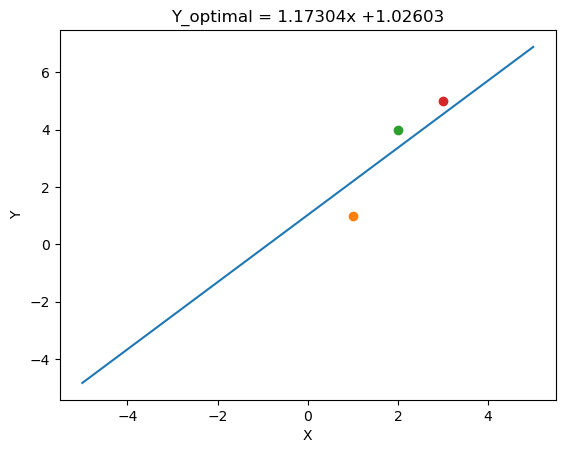

In [1]:
### Implementation

# Initial Values
points = np.matrix('1, 1 ; 2, 4 ; 3, 5')
Xdata = points[:3, :1]
Ydata = points[:3, 1:]
alpha = 0.01
N = 10

# Generating LR Model
cost, m, c = model1(alpha, N, Xdata, Ydata)

# Plotting LR Model and points
LR_plot(m, c, points)
plt.show()

To compare the LR models for different $\alpha$ and $N$, I shall draw several plots with varying $\alpha$ and $N$.

I shall use the final cost $J$ of the optimal line to compare models.

First, a line plot of $\log{J}$ against $\alpha$ for given $N's$ (N=1,10,100)

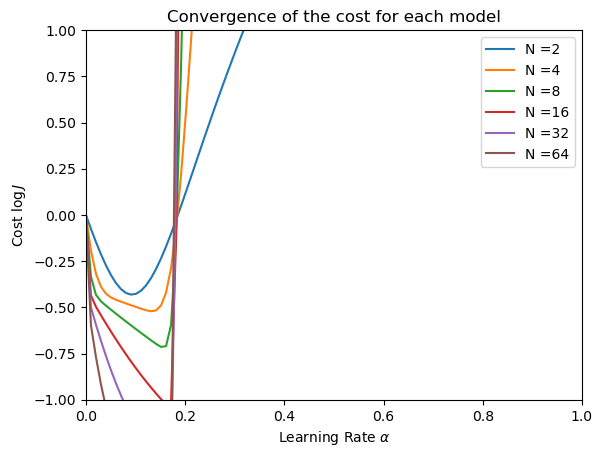

In [2]:
### Comparison

# Initial Values
points = np.matrix('1, 1 ; 2, 4 ; 3, 5')
Xdata = points[:3, :1]
Ydata = points[:3, 1:]
alpha = np.linspace(0,1, 100)
N = [2, 4, 8, 16, 32, 64]


# 2D line plots of J against Alpha for given N's
for i in range(len(N)):
    costs = []
    for x in alpha:
        cost, m, c = model1(x, N[i], Xdata, Ydata)
        costs.append(np.log(cost[-1]))
    costs = np.array(costs)
    
    plt.title(r"Convergence of the cost for each model")
    plt.xlabel(r"Learning Rate $\alpha$")
    plt.ylabel(r"Cost $\log{J}$")
    plt.axis([0, 1, -1, 1])
    
    plt.plot(alpha, costs, label= 'N =' + str(N[i]))

plt.legend()
plt.show()

#### Observations

There is an interval of $\alpha$,  $I_N \subseteq (0, 0.2)$ for each $N$, where $J$ is minimal. It seems that:

* $ I_{N} \subseteq I_{N+1}$

* $I_N \to I$ as $N \to \infty$ for some limiting interval $I \subseteq (0, 0.2)$.

* For any $\alpha \in I$, $J(\alpha) = J_{min}$ is constant. (where $J(\alpha)$ is $J(N = \infty, \alpha)$

* It is unclear whether $0 \in I$ or $0 \notin I$ as it seems $J_N$ will have a discontinuity as $N \to \infty$.

* $J_{min}$ is smaller for larger N.

* $J_{min}(N)$ is decreasing, bounded sequence $\implies$ it is convergent and cauchy.

For $\alpha \ge 0.2$, 

* $J$ shoots up to some large value as $\alpha \to 1$ for each $N$. 

* For larger $N$, $J$ shoots up more quickly as $\alpha$ increases.


From these observations, it is clear we can find a relatively small $N$ and optimal $\alpha \in (0, 0.2)$ such that the cost $J$ is minimal and calculations are not intensive for a simple Linear Regression Model trained on some small data set.


In [ ]:
# Hefty Calculation
N = [i for i in range(1,101)]

Z = []
for i in range(len(N)):
    costs = []
    for x in alpha:
        cost, m, c = model1(x, N[i], Xdata, Ydata)
        costs.append(np.log(cost[-1]))
    Z.append(costs)
Z = np.array(Z)

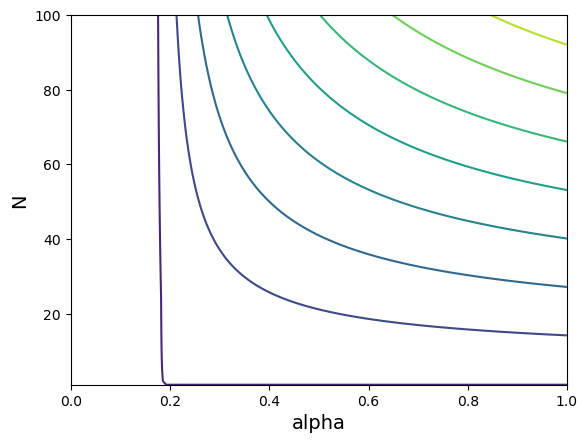

In [3]:
## Contour plot with J = f(N, alpha)

X, Y = np.meshgrid(alpha, N)

plt.contour(X, Y, Z)
plt.xlabel("alpha", fontsize=14)
plt.ylabel("N", fontsize=14)
plt.show()

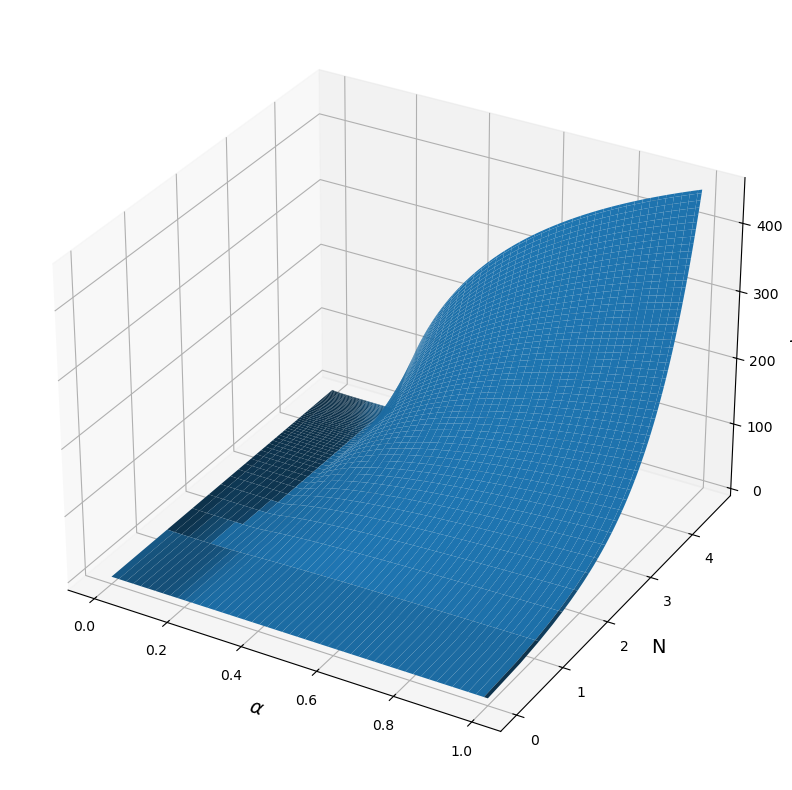

In [4]:
# initialise 3D plotting
fig = plt.figure(figsize=(10,10))
ax = plt.subplot(projection='3d')

# plot the surface
ax.plot_surface(X, np.log(Y), Z)

# label the axes
ax.set_xlabel(r"$\alpha$", fontsize=14)
ax.set_ylabel("N", fontsize=14)
ax.set_zlabel("J", fontsize=14)

plt.show()

## Binary classification with logistic regression

The dataset consists of a set of points $(x_0, x_1)$ in the plane, each of which is either blue or red. The model takes as input the coordinates of a point in the plane and returns 0 if the point is likely to be red, or 1 if the point is likely to be blue. In practice the model outputs a float between 0 and 1, which is the probability that the point is blue; 0.5 is then used as the threshold for classifying the point as blue or red.

#### The dataset

The cell below creates a planar dataset. It looks like a flower, with some red points and some blue points.

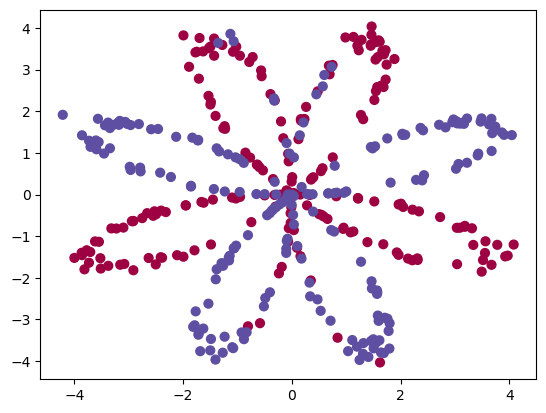

In [5]:
# Create the flower dataset

def load_flower_dataset():
    np.random.seed(1)

    m = 400 # number of examples
    N = int(m/2) # number of points per class
    D = 2 # dimensionality

    X = np.zeros((m,D)) # data matrix where each row is a single example
    y = np.zeros((m,1), dtype='uint8') # labels vector (0 for red, 1 for blue)
    a = 4 # maximum ray of the flower

    for j in range(2):
        ix = range(N*j,N*(j+1))
        t = np.linspace(j*3.12,(j+1)*3.12,N) + np.random.randn(N)*0.2 # theta
        r = a*np.sin(4*t) + np.random.randn(N)*0.2 # radius
        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        y[ix] = j

    X = X.T
    y = y.T

    return X, y

# Load the dataset:
X, y = load_flower_dataset()

# Visualize the dataset:
plt.scatter(X[0, :], X[1, :], c=y, s=40, cmap=plt.cm.Spectral);

The red points have label $y=0$ and the blue points have label $y=1$.

This creates two arrays `X` and `y` (shorthands for $X_{\text{train}}$ and $y_{\text{train}}$) containing 400 training examples:
- The numpy-array `X` of dimensions (2, 400); every column of `X` is the feature vector for a single training example and contains the coordinates of the point: $\begin{pmatrix} x_0 \\ x_1\end{pmatrix}$.
- The numpy-array `y` of dimensions (1,400); every column of `y` contains the label for a single training example (0 for red, 1 for blue).
- The columns of `X` correspond to the columns of `y`, i.e. the point in the first column of `X` corresponds to the first entry in `y` and so on.

The goal is to build a model to fit this data, in other words to define regions of the plane as either red or blue. Red regions correspond to points $(x_0,x_1)$ where the model returns a value less than 0.5, with any other parts of the plane being blue regions.

I start with a logistic regression model, built in numpy from scratch, and then measure its performance on this problem.

The steps to build the model are as follows.

1. Define the structure:
$$
\hat y = \sigma\left( W \cdot x+b \right)=\sigma\left(\begin{pmatrix} w_0 & w_1\end{pmatrix}\cdot \begin{pmatrix}x_0 \\ x_1\end{pmatrix}+b\right).
$$
For each example we take a linear combination $w_0x_0+w_1x_1+b$ of the input features $x_0$ and $x_1$, where $w_0,w_1,b$ are real numbers, followed by a *sigmoid* activation function $\sigma(\lambda)=\displaystyle\frac{1}{1+\exp(-\lambda)}$. The output $\hat y$ is the model's predicted probability that the point $x=\begin{pmatrix}x_0 \\ x_1\end{pmatrix}$ is blue. Here $W = \begin{pmatrix} w_0 & w_1\end{pmatrix}$ is the weight matrix and $b$ is the bias vector (which in this special case is actually a single value, a $1\times 1$ matrix).

2. Initialize the model's trainable parameters $W$ and $b$.

3. The training loop is then as follows:
    - Forward propagation: compute an array whose entries are $\hat{y}^{(i)}$ for each training example, with the current values of $W$ and $b$. Here $\hat{y}^{(i)}$ is the output probability for the example in column $i$ of $X$.
    - Compute the cost $J$ for the current values of the parameters.
    - Backward propagation to get the gradients, i.e. the rate of change of $J$ with respect to each of $w_0,w_1$ and $b$ at their current values.
    - Update the parameters using these gradients. This is gradient descent.

I build a helper function for each of these steps and then merge them into one function called `model()`. Once `model()` has been used to optimise the parameters, it can make predictions on new data.

#### Initialize parameters

The function `initialize_parameters` takes in the dimension of the input layer `n_X` and the dimension of the output layer `n_y` and returns a Python dictionary `parameters`. This dictionary contains the initialized parameters of the model: the weight matrix `W` and the bias vector `b`.

Note that `n_X = 2` in this example, since each point has two input coordinates, and the dimension of the output layer is `n_y = 1`. This means `W` is a $1\times 2$ matrix and `b` is a $1\times 1$ matrix here. The function is written more generally so that `n_X` and `n_y` can be specified as inputs, which allows it to be adapted for the neural network later on.

- `np.random.randn(n,m) * 0.01` randomly initializes a matrix of the required shape for `W`.
- The bias vector `b` is initialized so that all of its entries are zero.
- Both are returned in a dictionary called `parameters` with keys *W* and *b* respectively.

In [ ]:
def initialize_parameters(n_X, n_y):
    """
    Argument:
    n_X -- integer
    n_y -- integer

    Returns:
    parameters -- python dictionary containing the parameters:
                    W -- weight matrix
                    b -- bias vector
    """

    #Initialize weight matrix and bias vector
    W = np.random.randn(n_y,n_X) * 0.01
    b = np.zeros((n_y,1))

    #Store W and b in a dictionary parameters
    parameters = {"W": W,
                  "b": b}

    return parameters

#### Forward propagation

Forward propagation for logistic regression is

$$
z = WX + b \text{ and then }
\hat y = \sigma(z)
$$

where, for $\lambda\in\mathbb{R}$, $\sigma(\lambda)=\displaystyle\frac{1}{1+\exp(-\lambda)}$ (this is applied entry-wise to $z$ above).

The sigmoid function is implemented in numpy below.

In [ ]:
def sigmoid(z):
    """
    Argument:
    z -- input data, numpy array

    Returns:
    numpy array that contains sigmoid function applied to each
    element of z.
    """
    return 1/(1+np.exp(-z))

The function `forward_propagation` calculates the output of the logistic regression model, called `y_hat`, and returns (as a tuple) `y_hat` and `z`, in the notation given above.

In [ ]:
def forward_propagation(X, parameters):
    """
    Argument:
    X -- input data, numpy array of dimension (2, 400). Every column of X
         is the feature vector for a single training example (input of the logistic regression)
    parameters -- python dictionary containing the values of W and b to be used
                  to compute the forward propagation.

    Returns:
    y_hat -- numpy array of dimension (1,400). Every column of y_hat is the
             output probability of the logistic regression for that training example.
    z -- numpy array of dimension (1,400), result of linear transformation before sigmoid activation is applied.
    """

    # retrieve W and b from the dictionary "parameters"
    W = parameters["W"]
    b = parameters["b"]

    # compute z
    z = np.dot(W,X)+b

    # Compute y_hat
    y_hat = sigmoid(z)

    return y_hat, z

#### Compute cost

Given the predictions $\hat y^{(i)}$ on all the training examples, the cost $J$ is the average over all training examples of the losses:
$$
J = \frac{1}{m} \sum\limits_{i = 0}^{m} L(\hat y^{(i)}, y^{(i)})  .
$$
Here I use the binary cross-entropy loss:
$$
L(\hat y^{(i)}, y^{(i)}) = -\large\left(\small y^{(i)}\log\left(\hat y^{(i)}\right) + (1-y^{(i)})\log\left(1- \hat y^{(i)}\right)  \large  \right).
$$

Recall $y^{(i)}$ is the $i^{\text{th}}$ component in $y$, i.e. the label for example $i$, and $\hat{y}^{(i)}$ is the model's current prediction of this label, the $i^{\text{th}}$ component in $\hat{y}$.

The function `compute_cost()` computes the value of the cost $J$:

1. First it computes the vector of losses element-wise using the numpy arrays `y_hat` and `y`.

2. It sums the losses and divides by the number of training examples `m`.

3. It casts the result as type `float` and returns it.

In [ ]:
def compute_cost(y_hat, y):
    """
    Arguments:
    y_hat -- numpy array, output of forward propagation
    y -- numpy array of the same shape as y_hat, containing the true labels (0 for red, 1 for blue)

    Returns:
    cost -- a float which is the cross-entropy cost
    """

    # retrieve number of training examples from the shape of y
    m = y.shape[1]

    # compute the vector of losses by computing the cross-entropy loss element-wise
    loss =  y*np.log(y_hat)+(1-y)*np.log(1-y_hat)

    # compute the total cost by averaging the loss over all training examples
    cost = -np.sum(loss)/m

    # cast cost as a float
    cost = float(cost)

    return cost

#### Backpropagation

NOTATION: in general, for a generic numpy array `M` and a function $F$ with the entries of `M` as inputs, denote by `dM` the numpy array representing the gradient of $F$ with respect to `M`. More precisely `dM` contains the partial derivatives of $F$ with respect to the entries of `M`. For example if
$$M = \begin{pmatrix} a_{0,0} & a_{0,1} & a_{0,2} \\ a_{1,0} & a_{1,1} &  a_{1,2}\end{pmatrix}$$ and $F$ is a function of $a_{0,0},a_{0,1},a_{0,2},a_{1,0},a_{1,1},a_{1,2}$ then $$dM = \begin{pmatrix} \frac{\partial F}{\partial a_{0,0}} & \frac{\partial F}{\partial a_{0,1}} & \frac{\partial F}{\partial a_{0,2}} \\ \frac{\partial F}{\partial a_{1,0}} & \frac{\partial F}{\partial a_{1,1}} & \frac{\partial F}{\partial a_{1,2}}\end{pmatrix}.$$

Throughout, $F$ is the cost function $J$.

The function `backward_propagation()` takes in a dictionary `parameters` containing the current parameters, along with `y_hat`, `X` and `y`, and returns a dictionary containing the gradients `dW` and `db` of the cost function with respect to the trainable parameters `W` and `b`. In the notation above these are

`dz = y_hat - y
dW = np.dot(dz, X.T)/m
db = np.sum(dz, axis=1, keepdims=True)/m`

In [ ]:
def backward_propagation(parameters, y_hat, X, y):
    """
    Implement the backward propagation.

    Arguments:
    parameters -- python dictionary containing W and b to use
    y_hat - from output of forward prop
    X -- input data
    y -- labels vector

    Returns:
    grads -- python dictionary containing the gradients
    """
    # Retrieve the number of training examples from the shape of y
    m = y.shape[1]

    # retrieve W from the dictionary "parameters".
    W = parameters["W"]

    # Backward propagation: calculate dW, and db.
    dz = y_hat - y
    dW = np.dot(dz, X.T)/m
    db = np.sum(dz, axis=1, keepdims=True)/m

    grads = {"dW": dW,
             "db": db}

    return grads

#### Update parameters

The parameters are then updated by gradient descent, in the same way as for the linear regression above:

1. $W$ is updated to

$$W - dW\times \text{learning rate}$$

and

2. $b$ is updated to $$b - db\times\text{learning rate}.$$

The function `update_parameters()` takes in the dictionary `parameters` containing the current parameters `W` and `b`, the dictionary `grads` containing the current gradients `dW`, `db`, and the learning rate (which defaults to $1.2$).

In [ ]:
def update_parameters(parameters, grads, learning_rate = 1.2):
    """
    Arguments:
    parameters -- python dictionary containing the parameters
    grads -- python dictionary containing the gradients

    Returns:
    parameters -- python dictionary containing the updated parameters
    """
    # Retrieve a copy of each parameter from the dictionary "parameters"

    W = copy.deepcopy(parameters["W"])
    b = copy.deepcopy(parameters["b"])

    # Retrieve each gradient from the dictionary "grads"
    dW = grads["dW"]
    db = grads["db"]

    # Update each parameter
    W= W - dW * learning_rate
    b = b - db * learning_rate

    # Store the new parameters in the dictionary parameters
    parameters = {"W": W,
                  "b": b}

    return parameters

#### Model

Everything is now put together into a function `model`, which applies `update_parameters` iteratively to update the parameters a number of times.

It takes as inputs the training data `X`, `y`, a positive integer `num_iterations` which is the number of times the parameters are updated (defaulting to $10{,}000$), and a boolean `print_cost` which, when set to `True`, prints out some costs as the values of the parameters are updated. `model` returns a dictionary containing the optimised parameters at the end of this process.

In [ ]:
def model(X, y, num_iterations = 10000, print_cost=False):
    """
    Arguments:
    X -- numpy array, input data
    y -- numpy array, true labels
    num_iterations -- number of iterations in the gradient descent loop
    print_cost -- if True, print the cost every 1000 iterations

    Returns:
    parameters -- python dictionary which contains the optimized parameters
                  learnt by the model.
    """
    # Fix the random seed of the initialization for reproducibility
    np.random.seed(3)

    # retrieve n_x and n_y from X and y
    n_X = len(X)
    n_y = len(y)

    # Initialize parameters
    parameters = initialize_parameters(n_X, n_y)

    # Training loop (gradient descent)
    for i in range(0, num_iterations):

        # Forward propagation
        y_hat, z = forward_propagation(X, parameters)

        # Compute the cost
        cost = compute_cost(y_hat, y)

        # Backpropagation
        grads = backward_propagation(parameters, y_hat, X, y)

        # Update parameters (use learning_rate = 1.2)
        parameters = update_parameters(parameters, grads, learning_rate = 1.2)

        # Print the cost every 1000 iterations
        if print_cost and i % 1000 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))

    learned_parameters = parameters

    # return learned parameters
    return learned_parameters

#### Predict on new data

The function `predict` below uses the learned parameters (the output of `model`) and the `forward_propagation` function to predict a class for each example in the input matrix `X`.

In [ ]:
def predict(learned_parameters, X):
    """
    Arguments:
    parameters -- python dictionary containing the learned parameters given by model
    X -- numpy array input data

    Returns
    predictions -- vector of predictions for each column of X (red: 0 / blue: 1)
    """

    # Compute predicted probabilities using the learned parameters
    
    y_hat, z = forward_propagation(X, learned_parameters)

    # Classify as 0 or 1 using 0.5 as a threshold
    
    predictions = (y_hat > 0.5)

    return predictions

#### Plot the results and calculate accuracy

The function `plot_decision_boundary` below plots the decision boundary of the trained model along with the original data. It takes as arguments the `learned_parameters` (as output by the `model` function), the training examples `X` and the true labels `y`.

In [ ]:
# Function to plot decision boundary

def plot_decision_boundary(learned_parameters, X, y):

    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = predict(learned_parameters,np.c_[xx.ravel(), yy.ravel()].T)
    Z = Z.reshape(xx.shape)

    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x1')
    plt.xlabel('x0')
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral)
    plt.title("Decision Boundary")
    plt.show()

The model is now trained on the training examples, and the decision boundary for the learned parameters is plotted alongside the original data.

Cost after iteration 0: 0.693769
Cost after iteration 1000: 0.673146
Cost after iteration 2000: 0.673146
Cost after iteration 3000: 0.673146
Cost after iteration 4000: 0.673146
Cost after iteration 5000: 0.673146
Cost after iteration 6000: 0.673146
Cost after iteration 7000: 0.673146
Cost after iteration 8000: 0.673146
Cost after iteration 9000: 0.673146


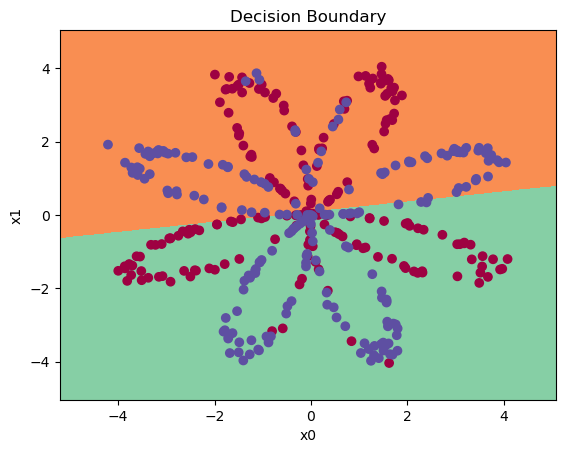

In [6]:
# Train the model
learned_parameters = model(X, y, num_iterations = 10000, print_cost=True)

# Plot the decision boundary
plot_decision_boundary(learned_parameters, X, y)


As the plot shows, logistic regression does not do a good job of predicting the labels for this dataset. This is because the dataset is not linearly separable, and so a simple logistic regression performs poorly on this data.

The accuracy below is the percentage of points for which the model gives the correct classification.

In [7]:
# Print accuracy

predictions = predict(learned_parameters, X)

# Percentage of points for which the prediction agrees with the actual label
accuracy = np.mean(predictions == y) * 100

print ('Accuracy of logistic regression: %d ' % accuracy +
       '% ' + "(percentage of correctly labelled datapoints)")

Accuracy of logistic regression: 47 % (percentage of correctly labelled datapoints)


## A neural network with one hidden layer

Next I build a full neural network with one hidden layer. This allows the model to learn more complex decision boundaries and not just linear ones, which should give an improved model compared to the logistic regression above.

In practice this repeats all of the steps above, but with an extra layer added to the network. The hidden layer has 4 neurons (in the code this dimension is denoted `n_h`).

The forward propagation has the form `linear`->`tanh`->`linear`->`sigmoid`. It takes the form below, where $W$ and $T$ are appropriately sized matrices containing weights and $b$ and $c$ are appropriately sized column vectors for the biases (some of the dimensions of these objects now depend on `n_h`). The input matrix $X$ is the same as before; $z$, $a$, $v$ give intermediate output, with $\hat y$ the final output.

$$
z = W\cdot X + b \\
a = \tanh(z) \\
v = T \cdot a + c \\
\hat y = \sigma(v)
$$

In this notation, the gradients for the new backward propagation are

`dv = y_hat - y
dT = np.dot(dv, a.T)/m
dc = np.sum(dv, axis=1, keepdims=True)/m
dz = np.dot(T.T, dv) * (1 - np.power(a, 2))
dW = np.dot(dz, X.T)/m
db = np.sum(dz, axis=1, keepdims=True)/m`

The cost is the same as for logistic regression, so it is reused rather than implemented again.

#### Neural network model

The helper functions below — initialization, forward propagation, backward propagation and the parameter update — are built from scratch and then combined into `model_nn`, following the same structure as the logistic regression model above. Functions and variables are renamed where necessary to avoid clashes with the values already established for the logistic regression.

`predict_nn` then takes in the dictionary of parameters and the input data `X` and returns predictions of the labels for each example, the regions of the plane predicted to be red or blue are visualised alongside the original data, and the accuracy of the model is calculated.

#### Initialize

In [ ]:
def initialize_parameters_nn(n_X, n_y, n_h):
    """
    Argument:
    n_X -- integer
    n_y -- integer

    Returns:
    parameters -- python dictionary containing your parameters:
                    W -- weight matrix
                    b -- bias vector
    """

    #Initialize weight matrix and bias vector
    # First layer (Input layer to Hidden layer)
    # W connects n_X inputs to n_h hidden neurons
    W = np.random.randn(n_h, n_X) * 0.01
    b = np.zeros((n_h, 1))
    
    #Second layer (Hidden layer to Output layer)
    # T connects n_h hidden neurons to n_y output neurons
    T = np.random.randn(n_y, n_h) * 0.01
    c = np.zeros((n_y, 1))

    #Store W, b, T and c in a dictionary parameters
    parameters = {"W": W,
                  "b": b,
                  "T": T,
                  "c": c}

    return parameters

#### Forward propagation

In [ ]:
def forward_propagation_nn(X, parameters):
    """
    Argument:
    X -- input data, numpy array of dimension (2, 400). Every column of X
         is the feature vector for a single training example (input of the logistic regression)
    parameters -- python dictionary containing the values of W and b to be used
                  to compute the forward propagation.

    Returns:
    y_hat -- numpy array of dimension (1,400). Every column of y_hat is the
             output probability of the logistic regression for that training example.
    z -- numpy array of dimension (1,400), result of linear transformation before sigmoid activation is applied.
    """

    # retrieve W, b, T and c from the dictionary "parameters"
    W = parameters["W"]
    b = parameters["b"]
    T = parameters["T"]
    c = parameters["c"]

    # compute z
    z = np.dot(W,X)+b
    # Apply the tanh activation function
    a = np.tanh(z)
    # compute v
    v = np.dot(T,a)+c
    

    # apply the sigmoid activation function(The predicted y value)
    y_hat = sigmoid(v)

    # return the hidden layer's output and predicted y value
    return y_hat, a

#### Backward propagation

In [ ]:
def backward_propagation_nn(parameters, y_hat, X, y, a):
    """
    Implement the backward propagation.

    Arguments:
    parameters -- python dictionary containing W and b to use
    y_hat - from output of forward prop
    X -- input data
    y -- labels vector

    Returns:
    grads -- python dictionary containing the gradients
    """
    # Retrieve the number of training examples from the shape of y
    m = y.shape[1]

    # retrieve T from the dictionary "parameters".
    T = parameters["T"]

    # Backward propagation: calculate dW, db, dT, and dc.
    dv = y_hat - y
    dT = np.dot(dv, a.T)/m
    dc = np.sum(dv, axis=1, keepdims=True)/m
    dz = np.dot(T.T, dv) * (1 - np.power(a, 2))
    dW = np.dot(dz, X.T)/m
    db = np.sum(dz, axis=1, keepdims=True)/m

    #Store dW, db, dT and dc in a dictionary grads
    grads = {"dW": dW,
             "db": db,
             "dT": dT,
             "dc": dc,}

    # Return the dictionary grads
    return grads

#### Update parameters

In [ ]:
def update_parameters_nn(parameters, grads, learning_rate = 1.2):
    """
    Arguments:
    parameters -- python dictionary containing the parameters
    grads -- python dictionary containing the gradients

    Returns:
    parameters -- python dictionary containing the updated parameters
    """

    # Retrieve a copy of each parameter from the dictionary "parameters". Use copy.deepcopy(...)
    
    W = copy.deepcopy(parameters["W"])
    b = copy.deepcopy(parameters["b"])
    T = copy.deepcopy(parameters["T"])
    c = copy.deepcopy(parameters["c"])

    # Retrieve each gradient from the dictionary "grads"
    dW = grads["dW"]
    db = grads["db"]
    dT = grads["dT"]
    dc = grads["dc"]

    # Update each parameter (Gradient descent)
    W= W - dW * learning_rate
    b = b - db * learning_rate
    T= T - dT * learning_rate
    c = c - dc * learning_rate

    # Store the new parameters in the dictionary parameters
    parameters = {"W": W,
                  "b": b,
                  "T": T,
                  "c": c}

    return parameters

In [ ]:
def model_nn(X, y, n_h = 4, num_iterations = 10000, print_cost=False):
    """
    Arguments:
    X -- numpy array, input data
    y -- numpy array, true labels
    n_h -- integer, number of neurons in the hidden layer
    num_iterations -- number of iterations in the gradient descent loop
    print_cost -- if True, print the cost every 1000 iterations

    Returns:
    parameters -- optimized parameters learnt by the model.
    """
    # Fix the random seed of the initialization for reproducibility
    np.random.seed(3)

    # retrieve n_x and n_y
    n_X = len(X)
    n_y = len(y)

    # Initialize parameters
    parameters = initialize_parameters_nn(n_X, n_y, n_h)


    # Training loop
    for i in range(0, num_iterations):

        # Forward propagation
        y_hat, a = forward_propagation_nn(X, parameters)

        # Compute cost
        cost = compute_cost(y_hat, y)

        # Backpropagation
        grads = backward_propagation_nn(parameters, y_hat, X, y, a)

        # Update parameters
        parameters = update_parameters_nn(parameters, grads)

        # Print the cost every 1000 iterations
        if print_cost and i % 1000 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))

        learned_parameters = parameters

    return learned_parameters

In [ ]:
def predict_nn(learned_parameters_nn, X):
    """
    Arguments:
    parameters -- python dictionary containing the learned parameters given by model
    X -- numpy array input data

    Returns
    predictions -- vector of predictions for each column of X (red: 0 / blue: 1)
    """

    # Compute predicted probabilities using the learned parameters
    
    y_hat, a = forward_propagation_nn(X, learned_parameters_nn)

    # Classify as 0 or 1 using 0.5 as a threshold
    
    predictions = (y_hat > 0.5)

    return predictions

In [ ]:
def plot_decision_boundary_nn(learned_parameters_nn, X, y):

    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = predict_nn(learned_parameters_nn,np.c_[xx.ravel(), yy.ravel()].T)
    Z = Z.reshape(xx.shape)

    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x1')
    plt.xlabel('x0')
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral)
    plt.title("Decision Boundary")
    plt.show()

Cost after iteration 0: 0.693162
Cost after iteration 1000: 0.258625
Cost after iteration 2000: 0.239334
Cost after iteration 3000: 0.230802
Cost after iteration 4000: 0.225528
Cost after iteration 5000: 0.221845
Cost after iteration 6000: 0.219094
Cost after iteration 7000: 0.220609
Cost after iteration 8000: 0.219410
Cost after iteration 9000: 0.218526


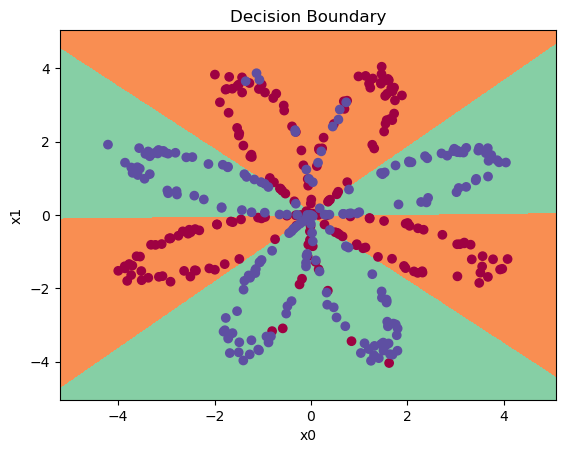

In [8]:
# Train the model
learned_parameters_nn = model_nn(X, y, num_iterations = 10000, print_cost=True)

# Plot the decision boundary
plot_decision_boundary_nn(learned_parameters_nn, X, y)

In [9]:
predictions = predict_nn(learned_parameters_nn, X)

accuracy = np.mean(predictions == y) * 100

print ('Accuracy of the neural network: %d ' % accuracy +
       '% ' + "(percentage of correctly labelled datapoints)")

Accuracy of the neural network: 90 % (percentage of correctly labelled datapoints)


## Polynomial regression

Polynomial regression is an extension of linear regression and can be used when the relationship between variables is non-linear. This is much more flexible than linear regression. It is a form of supervised learning, so the model is trained on labelled data (known input and output). The model tries to fit a curve to data and predict new data.

If the order of the polynomial is too high, there is a risk of overfitting, on the other hand, if the order is too low, there is a risk of underfitting. To find the line of best fit, we fit polynomials of different orders to the data and then use BIC (Bayes information criterion) to evaluate the fit.

For each of the different lines, you calculate the BIC, and then select the polynomial, with the lower BIC. The BIC rewards minimising SRR (the summed squares of all the residuals), but also penalises using too many parameters, therefore a balance of fitting and complexity is found. A complicated model is only preferred if it reduces costs enough. [1]

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Make some example data
np.random.seed(0)
x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 0.5 * x[:, 0]**3 - x[:, 0]**2 + 2 * x[:, 0] + 3
y = y + np.random.normal(0, 3, len(y)) #add some noise

n = len(y)

models = {}
polynomials = {}

# Try different polynomial degrees
for degree in range(1, 7):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(x)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)

    rss = np.sum((y - y_pred) ** 2) #Calculating loss
    k = degree + 1
    bic = n * np.log(rss / n) + k * np.log(n) #calculating the BIC

    models[degree] = model
    polynomials[degree] = poly

    print("Degree:", degree, " BIC:", round(bic, 2), " RSS:", rss)


Degree: 1  BIC: 277.8  RSS: 1467.1314755565907
Degree: 2  BIC: 264.38  RSS: 1225.1506130674293
Degree: 3  BIC: 222.25  RSS: 767.749763176323
Degree: 4  BIC: 226.84  RSS: 767.604682748191
Degree: 5  BIC: 230.2  RSS: 758.129716537931
Degree: 6  BIC: 234.75  RSS: 757.7380201263694


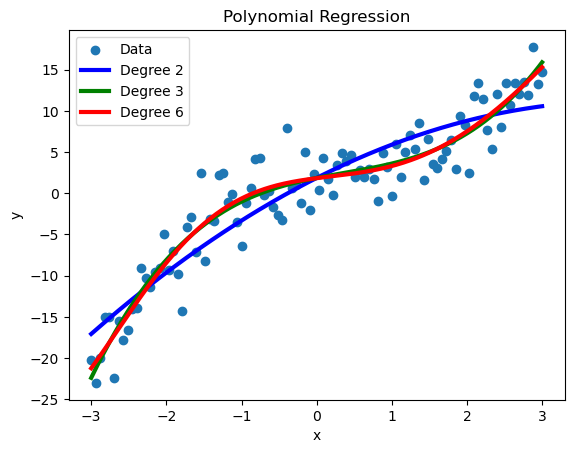

In [11]:

x_graph = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.scatter(x, y, label="Data")

for degree in [2, 3, 6]:
    X_graph_poly = polynomials[degree].transform(x_graph)
    y_graph = models[degree].predict(X_graph_poly)

    if degree == 2:
        plt.plot(x_graph, y_graph, color="blue", linewidth=3, label="Degree 2")
    elif degree == 3:
        plt.plot(x_graph, y_graph, color="green", linewidth=3, label="Degree 3")
    elif degree == 6:
        plt.plot(x_graph, y_graph, color="red", linewidth=3, label="Degree 6")
        
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

As you can see, too low of an order (e.g 2) underfits the data, and has a large SSR and BIC, too high of an order (e.g 6), overfits the data, and doesn't decrease the SSR very much but adds lots of complexity, increasing it's BIC. [2]

### References

[1] Geeksforgeeks, Bayesian Information Criterion (BIC). 2025. https://www.geeksforgeeks.org/machine-learning/bayesian-information-criterion-bic/ (last accessed 25th March 2026)

[2] Scikit-learn example: "Underfitting vs Overfitting" https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html (last accessed 25th March 2026)